# Phase 1: Tokenization Comparison

In [1]:
import tensorflow as tf
tf.keras.utils.disable_interactive_logging()

2026-03-09 12:59:22.402012: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-03-09 12:59:22.402356: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-09 12:59:22.439945: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-03-09 12:59:23.309114: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation or

In [2]:
from datasets import load_dataset
ds = load_dataset("szzs1693/intro-nlp-thai-news")
df = ds["train"].to_pandas()
df.head()

,url,date,title,body_text,category,source
0,https://prachatai.com/print/2575,2005-02-03 02:09:00,ปากคำแก๊งหน้าดารา : อันธพาลกวนเมือง หรือ?,คดีซามูไรผมแดงครั้งนั้น กลายเป็นข่าวใหญ่โตทั้ง...,social,prachathai
1,https://prachatai.com/print/4921,2005-07-16 10:17:00,วิษณุแจงออก พ.ร.ก.. ฉุกเฉินเพื่อบูรณาการกฎหมาย,[1]\nประชาไท15 ก.ค. 2548 นายวิษณุ เครืองาม รอ...,politics,prachathai
2,https://prachatai.com/print/4923,2005-07-16 10:18:00,คำอธิบายพระราชกำหนดบริหารราชการในสถานการณ์ฉุกเ...,ภายหลังการประชุมคณะรัฐนตรีนัดพิเศษ นายวิษณุ เค...,politics,prachathai
3,https://prachatai.com/print/4939,2005-07-18 01:49:00,อนุกรรมการสมานฉันท์ฯถกพรก.ฉุกเฉิน,นายอับดุลอาซิซ ตาเดอินทร์ รองนายกสมาคมยุวมุสลิ...,politics,prachathai
4,https://prachatai.com/print/4945,2005-07-18 16:26:00,"โพลระบุ ""คน 3 จว.ใต้-กทม."" หนุนรัฐออกกม.สถานกา...",สำนักวิจัยเอแบคโพลล์ มหาวิทยาลัยอัสสัมชัญ ได้ส...,politics,prachathai


In [3]:
%pip install pythainlp attacut

Note: you may need to restart the kernel to use updated packages.


In [4]:
from pythainlp.tokenize import word_tokenize, subword_tokenize

def tokenize_word(text: str) -> str:
    tokens = word_tokenize(text, engine="newmm", keep_whitespace=False)
    return tokens

def tokenize_subword(text: str) -> str:
    tokens = subword_tokenize(text, engine="wangchanberta", keep_whitespace=False)
    return tokens

In [5]:
from tqdm import tqdm
tqdm.pandas(desc="Tokenize with Neural")
df["subword_tokenized"] = df["body_text"].progress_apply(tokenize_subword)

Tokenize with Neural: 100%|██████████| 6603/6603 [00:28<00:00, 228.29it/s]


In [6]:
from tqdm import tqdm
tqdm.pandas(desc="Tokenize with Dict")
df["word_tokenized"] = df["body_text"].progress_apply(tokenize_word)

Tokenize with Dict: 100%|██████████| 6603/6603 [00:38<00:00, 171.96it/s]


In [7]:
df["word_tokenized"].str.len().describe()

count     6603.000000
mean       963.450704
std       1071.147437
min         65.000000
25%        411.000000
50%        661.000000
75%       1112.000000
max      15357.000000
Name: word_tokenized, dtype: float64

In [8]:
df["subword_tokenized"].str.len().describe()

count     6603.000000
mean      1139.994548
std       1299.880805
min         76.000000
25%        501.000000
50%        787.000000
75%       1292.500000
max      28087.000000
Name: subword_tokenized, dtype: float64

In [9]:
import pandas as pd
pd.set_option('display.max_colwidth', None)

sampled = df.sample(5, random_state=42)
sampled[["word_tokenized","subword_tokenized"]]

,word_tokenized,subword_tokenized
1483,"[สื่อ, อำมาตย์, ต้องการ, หล่อหลอม, ให้, เยาวชน, ดูถูก, เหยียดหยาม, ผู้, เ, เท, น, ประชาชน, ... “, ระบอบ, รัฐธรรมนูญ, 2550, และ, รัฐบาล, พรรคประชาธิปัตย์, เป็น, กรณี, ตัวอย่าง, รวบยอด, ที่, แสดงถึง, จุดประสงค์, ที่, แท้จริง, ใน, การ, ใช้ประโยชน์, จาก, ระบอบ, รัฐสภา, โดย, เผด็จการ, อำมาตยาธิปไตย, สิ่ง, ที่, พวกเขา, ต้องการ, คือ, รัฐสภา, ที่, ประกอบด้วย, พรรคการเมือง, ขนาดเล็ก, ที่, อ่อนแอ, ให้, มี, รัฐบาล, หุ่นเชิด, ไร้, อำนาจ, ที่, แท้จริง, ใน, การบริหาร, แผ่นดิน, แต่, ต้อง, อยู่, ภายใต้, อำนาจ, แฝงเร้น, ของ, เผด็จการ, อำมาตยาธิปไตย, เป็น, รัฐบาล, ที่, ไร้ความสามารถ, และ, ไม่, อาจ, แก้ปัญหา, ของ, ประชาชน, ได้, เต็มไปด้วย, การ, ทุจริต, คอรัปชั่น, ทั้งหมด, นี้, ก็, เพื่อ, แสดง, ให้, ประชาชน, เห็น, ว่า, ระบอบประชาธิปไตย, และ, การเลือกตั้ง, นั้น, เป็น, สิ่งชั่วร้าย, ...]","[▁, สื่อ, อ, ำ, มา, ต, ย์, ต้องการ, หล่อ, หลอม, ให้, เยาวชน, ดูถูก, เหยียดหยาม, ผู้, เเทน, ประชาชน, ..., , “, ระบอบ, รัฐธรรมนูญ, ▁, 2550, ▁, และรัฐบาล, พรรคประ, ชาธิปัตย์, ▁, เป็น, กรณี, ตัวอย่าง, รวบ, ยอด, ที่, แสดงถึง, จุดประสงค์, ที่แท้จริง, ในการใช้, ประโยชน์, จาก, ระบอบ, รัฐสภา, โดย, เผด็จการ, อ, ำ, มา, ต, ย, า, ธิปไตย, ▁สิ่งที่, พวกเขา, ต้องการ, คือ, ▁, รัฐสภา, ที่, ประกอบด้วย, พรรค, การเมือง, ขนาดเล็ก, ที่, อ่อนแอ, ▁, ให้มี, รัฐบาล, หุ่น, เชิด, ไร้, อ, ำ, น, า, จ, ที่แท้จริง, ใน, การบริหาร, แผ่นดิน, ▁, แต่ต้อง, อยู่ภายใต้, อ, ำ, น, า, จ, แฝง, เร้น, ของ, เผด็จการ, อ, ำ, มา, ต, ย, า, ธิปไตย, ▁, ...]"
4264,"[แม่, ที่, มี, เชื้อ, เอชไอวี, กำลัง, อุ้ม, ลูกชาย, วัย, 3, ขวบ, ที่เกิด, มา, โดย, ไม่, ได้รับ, เชื้อ, วันนี้, ประเทศ, ได้รับ, การ, รับรอง, อย่าง, เป็นทางการ, ว่า, สามารถ, ยุติ, การ, ถ่ายทอด, เชื้อ, เอชไอวี, และ, ซิฟิลิส, จาก, แม่, สู่, ลูก, ได้, สำเร็จ, (, ที่มา, ภาพ, , ยูนิเซฟ, โดย, Jingjai, N, .), \n, 8, มิ.ย., 2559, รายงาน, ข่าว, จาก, องค์การ, ยูนิเซฟ, ประเทศ, ไทย, แจ้ง, ว่า, , ประเทศ, ไทย, ได้รับ, การ, รับรอง, อย่าง, เป็นทางการ, ว่า, สามารถ, ยุติ, การ, ถ่ายทอด, เชื้อ, เอชไอวี, และ, ซิฟิลิส, จาก, แม่, สู่, ลูก, ได้, สำเร็จ, โดย, เป็น, ประเทศ, แรก, ใน, ภูมิภาค, เอเชีย, และ, เป็น, ประเทศ, แรก, ๆ, ของ, โลก, ที่, สามารถ, ...]","[▁แม่, ที่มี, เชื้อ, เอชไอวี, ก, ำ, ลัง, อุ้ม, ลูกชาย, วัย, ▁, 3, ▁, ขวบ, ที่, เกิดมา, โดย, ไม่ได้รับ, เชื้อ, ▁วันนี้, ประเทศ, ได้รับการ, รับรอง, อย่าง, เป็นทางการ, ว่า, สามารถ, ยุติการ, ถ่ายทอด, เชื้อ, เอชไอวี, และ, ซิ, ฟิ, ลิส, จาก, แม่, สู่, ลูก, ได้, ส, ำ, เร็, จ, ▁(, ที่มาภาพ, , ยูนิ, เซฟ, ▁โดย, ▁, J, ing, ja, i, ▁, N, ., ), ▁, 8, ▁, มิ, ., ย, ., ▁, 2559, ▁, รายงานข่าว, จาก, องค์การ, ยูนิ, เซฟ, ▁, ประเทศไทย, ▁, แจ้งว่า, , ประเทศไทย, ได้รับการ, รับรอง, อย่าง, เป็นทางการ, ว่า, สามารถ, ยุติการ, ถ่ายทอด, เชื้อ, เอชไอวี, และ, ซิ, ฟิ, ลิส, จาก, แม่, สู่, ลูก, ได้, ส, ...]"
239,"[S, .H.A.N., (14, พฤษภาคม, 2549, ), -, กองกำลัง, ว้า, แดง, UWSA, เตรียม, ขยาย, พื้นที่, ครอบครอง, ตาม, แนว, ชายแดน, ไทย, พร้อม, ส่ง, กำลัง, ทหาร, จาก, เหนือ, ลง, ใต้, อย่าง, ต่อเนื่อง, และ, เมื่อ, ช่วง, กลางเดือน, เมษายน, ที่ผ่านมา, ได้, อพยพ, ประชากร, ของ, ตน, ลงมา, ทางใต้, รัฐ, ฉาน, อีก, กว่า, 2, พัน, คน, ซึ่ง, มี, ทหาร, แอบแฝง, อยู่, ด้วย, ด้าน, นักวิเคราะห์, ชี้, หาก, กองกำลัง, ว้า, กระทำการ, ดังกล่าว, จริง, ไทย, อาจ, ได้รับ, ผลกระทบ, จาก, การ, ทะลัก, เข้ามา, ของ, ยาเสพติด, และ, ผู้อพยพ, จาก, การ, สู้รบ, ที่, อาจ, เกิดขึ้น, \n, เมื่อ, กลางเดือน, เมษายน, 2549, ที่ผ่านมา, กองกำลัง, ว้า, แดง, UWSA, ได้, อพยพ, ประชากร, ของ, ตน, จาก, ภาค, ตะวันออกเฉียงเหนือ, ...]","[▁, S, ., H, ., A, ., N, ., ▁(, 14, ▁, พฤษภาคม, ▁, 2549, ), ▁-, ▁, กอง, ก, ำ, ลัง, ว้า, แดง, ▁, UWSA, ▁เตรียม, ขยาย, พื้นที่, ครอบครอง, ตามแนว, ชายแดนไทย, พร้อมส่ง, ก, ำ, ลัง, ทหาร, จาก, เหนือ, ลง, ใต้, อย่าง, ต่อเนื่อง, ▁และ, เมื่อช่วง, กลางเดือน, เมษายน, ที่ผ่านมา, ▁, ได้, อพยพ, ประชากร, ของตน, ลงมา, ทางใต้, รัฐฉาน, อีกกว่า, ▁, 2, ▁, พันคน, ▁, ซึ่งมี, ทหาร, แอบแฝง, อยู่ด้วย, ▁ด้าน, นัก, วิเคราะห์, ชี้, หาก, กอง, ก, ำ, ลัง, ว้า, กระ, ท, ำ, การ, ดังกล่าว, จริง, ไทย, อาจ, ได้รับ, ผลกระทบจาก, การ, ทะลัก, เข้ามา, ของ, ยาเสพติด, และ, ผู้อพยพ, จาก, การสู้รบ, ที่อาจ, เกิดขึ้น, ▁เมื่อ, กลางเดือน, เมษายน, ...]"
3501,"[ย้อนกลับ, ไป, เมื่อ, วันที่, 1, ต.ค., 2557, หลังจาก

## Vocabulary Size

In [10]:
word_vocab = set(token for tokens in df["word_tokenized"] for token in tokens)
subword_vocab = set(token for tokens in df["subword_tokenized"] for token in tokens)

print(f"Word-level vocabulary size:    {len(word_vocab):,}")
print(f"Subword-level vocabulary size: {len(subword_vocab):,}")

Word-level vocabulary size:    73,709
Subword-level vocabulary size: 25,640


## Token Count Distribution

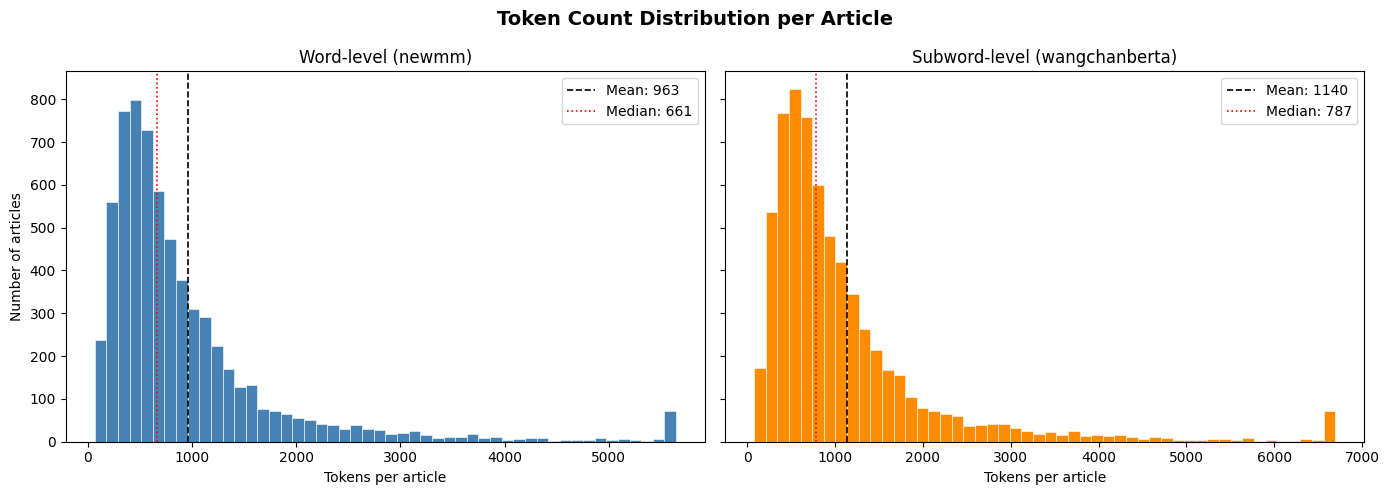

In [11]:
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams["font.family"] = "DejaVu Sans"

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for ax, col, label, color in zip(
    axes,
    ["word_tokenized", "subword_tokenized"],
    ["Word-level (newmm)", "Subword-level (wangchanberta)"],
    ["steelblue", "darkorange"],
):
    lengths = df[col].str.len()
    # Cap at 99th percentile to avoid extreme outliers compressing the chart
    cap = int(lengths.quantile(0.99))
    ax.hist(lengths.clip(upper=cap), bins=50, color=color, edgecolor="white", linewidth=0.4)
    ax.axvline(lengths.mean(), color="black", linestyle="--", linewidth=1.2, label=f"Mean: {lengths.mean():.0f}")
    ax.axvline(lengths.median(), color="red", linestyle=":", linewidth=1.2, label=f"Median: {lengths.median():.0f}")
    ax.set_title(label)
    ax.set_xlabel("Tokens per article")
    ax.legend()

axes[0].set_ylabel("Number of articles")
fig.suptitle("Token Count Distribution per Article", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

## OOV (Out-of-Vocabulary) Analysis

Word-level tokenization relies on a dictionary. Tokens not found in the dictionary are considered OOV — they may appear as single characters or short fragments. Subword tokenization has no OOV by design, as it falls back to character-level splitting.

In [12]:
from pythainlp.corpus.common import thai_words

dictionary = thai_words()

def oov_rate(tokens):
    if not tokens:
        return 0.0
    oov = [t for t in tokens if t not in dictionary and t.strip()]
    return len(oov) / len(tokens)

df["word_oov_rate"] = df["word_tokenized"].apply(oov_rate)

print("Word-level OOV rate (tokens not in pythainlp dictionary):")
print(df["word_oov_rate"].describe())
print(f"\nMean OOV rate: {df['word_oov_rate'].mean():.2%}")
print(f"Subword OOV rate: 0% (no OOV by design — unknown tokens are split into subword/character units)")

Word-level OOV rate (tokens not in pythainlp dictionary):
count    6603.000000
mean        0.082234
std         0.049472
min         0.000000
25%         0.050770
50%         0.071556
75%         0.100484
max         0.632825
Name: word_oov_rate, dtype: float64

Mean OOV rate: 8.22%
Subword OOV rate: 0% (no OOV by design — unknown tokens are split into subword/character units)


## Qualitative Analysis

We examine how each tokenizer handles specific linguistic patterns common in Thai news: compound words, named entities, and foreign/rare vocabulary.

In [13]:
from pythainlp.tokenize import word_tokenize, subword_tokenize

examples = {
    "Compound word (political term)": "คณะกรรมการการเลือกตั้ง",
    "Named entity (organization)": "ธนาคารเพื่อการเกษตรและสหกรณ์การเกษตร",
    "Foreign acronym": "UWSA ปะทะกับกองกำลัง",
    "Rare/domain-specific term": "อำมาตยาธิปไตย",
    "Mixed Thai-English": "รัฐบาลออก พ.ร.ก. ฉุกเฉิน",
}

rows = []
for description, text in examples.items():
    w_tokens = word_tokenize(text, engine="newmm", keep_whitespace=False)
    s_tokens = subword_tokenize(text, engine="wangchanberta", keep_whitespace=False)
    rows.append({
        "Description": description,
        "Text": text,
        "Word-level tokens": w_tokens,
        "Word count": len(w_tokens),
        "Subword tokens": s_tokens,
        "Subword count": len(s_tokens),
    })

qual_df = pd.DataFrame(rows)
pd.set_option("display.max_colwidth", None)
qual_df[["Description", "Text", "Word-level tokens", "Word count", "Subword tokens", "Subword count"]]

,Description,Text,Word-level tokens,Word count,Subword tokens,Subword count
0,Compound word (political term),คณะกรรมการการเลือกตั้ง,"[คณะกรรมการ, การเลือกตั้ง]",2,"[▁, คณะกรรมการ, การ, เลือกตั้ง]",4
1,Named entity (organization),ธนาคารเพื่อการเกษตรและสหกรณ์การเกษตร,[ธนาคารเพื่อการเกษตรและสหกรณ์การเกษตร],1,"[▁, ธนาคาร, เพื่อ, การเกษตร, และสหกรณ์, การเกษตร]",6
2,Foreign acronym,UWSA ปะทะกับกองกำลัง,"[UWSA, ปะทะ, กับ, กองกำลัง]",4,"[▁, UWSA, ▁, ปะทะกับ, กอง, ก, ำ, ลัง]",8
3,Rare/domain-specific term,อำมาตยาธิปไตย,[อำมาตยาธิปไตย],1,"[▁อ, ำ, มา, ต, ย, า, ธิปไตย]",7
4,Mixed Thai-English,รัฐบาลออก พ.ร.ก. ฉุกเฉิน,"[รัฐบาล, ออก, พ.ร.ก., ฉุกเฉิน]",4,"[▁รัฐบาล, ออก, ▁, พ, ., ร, ., ก, ., ▁, ฉุกเฉิน]",11
